# Chapter 5: Cluster Analysis 
### Apil Maraseni 
### ACE079BCT012


## Objective

The objective of this implementation is to perform cluster analysis on the Online Retail dataset using three different clustering algorithms:

1. K-Means Clustering
2. Hierarchical Clustering
3. DBSCAN Clustering

The clustering results will be evaluated and compared using appropriate clustering evaluation metrics.

## 1. Import Required Libraries

The required Python libraries are imported for data preprocessing, visualization, clustering, and evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings("ignore")

## 2. Load the Dataset


In [2]:
file_path = "Online_Retail.csv"

df = pd.read_csv(file_path, encoding="ISO-8859-1")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset Shape: (541909, 8)

Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


## 3. Dataset Exploration


In [3]:
print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nStatistical Summary:")
df.describe()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 66.2 MB

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicate Rows: 5268

Statistical Summary:


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## 4. Data Preprocessing

The raw transactional data requires preprocessing before clustering.

The following preprocessing steps are performed:

1. Remove duplicate records.
2. Remove cancelled transactions.
3. Remove records with missing customer IDs.
4. Remove records with missing product descriptions.
5. Remove transactions with non-positive quantities.
6. Remove transactions with non-positive unit prices.
7. Convert the invoice date into a datetime format.
8. Calculate the total amount spent for each transaction.

In [4]:
# Make a copy of the dataset
data = df.copy()

# Remove duplicate records
data = data.drop_duplicates()

# Remove cancelled transactions
data = data[~data["InvoiceNo"].astype(str).str.startswith("C")]

# Remove missing CustomerID
data = data.dropna(subset=["CustomerID"])

# Remove missing Description
data = data.dropna(subset=["Description"])

# Keep only positive quantities
data = data[data["Quantity"] > 0]

# Keep only positive unit prices
data = data[data["UnitPrice"] > 0]

# Convert InvoiceDate to datetime
data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"])

# Calculate transaction amount
data["TotalAmount"] = data["Quantity"] * data["UnitPrice"]

print("Shape after preprocessing:", data.shape)

Shape after preprocessing: (392692, 9)


## 5. Customer-Level RFM Analysis

The original dataset contains individual transaction records. Clustering individual transaction rows would not provide a meaningful customer segmentation.

Therefore, the transactional data is aggregated at the customer level using RFM analysis.

### RFM Features

- **Recency** measures how recently a customer purchased.
- **Frequency** measures how frequently a customer purchased.
- **Monetary** measures the total amount spent by a customer.

These three features provide a compact numerical representation of customer purchasing behavior.


In [5]:
# Reference date: one day after the last transaction
reference_date = data["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = data.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalAmount", "sum")
).reset_index()

print("RFM Dataset Shape:", rfm.shape)

rfm.head()

RFM Dataset Shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


## 6. RFM Dataset Exploration


In [6]:
print(rfm.describe())

print("\nMissing Values:")
print(rfm.isnull().sum())

         CustomerID      Recency    Frequency       Monetary
count   4338.000000  4338.000000  4338.000000    4338.000000
mean   15300.408022    92.536422     4.272015    2048.688081
std     1721.808492   100.014169     7.697998    8985.230220
min    12346.000000     1.000000     1.000000       3.750000
25%    13813.250000    18.000000     1.000000     306.482500
50%    15299.500000    51.000000     2.000000     668.570000
75%    16778.750000   142.000000     5.000000    1660.597500
max    18287.000000   374.000000   209.000000  280206.020000

Missing Values:
CustomerID    0
Recency       0
Frequency     0
Monetary      0
dtype: int64


## 7. Visualization of RFM Features


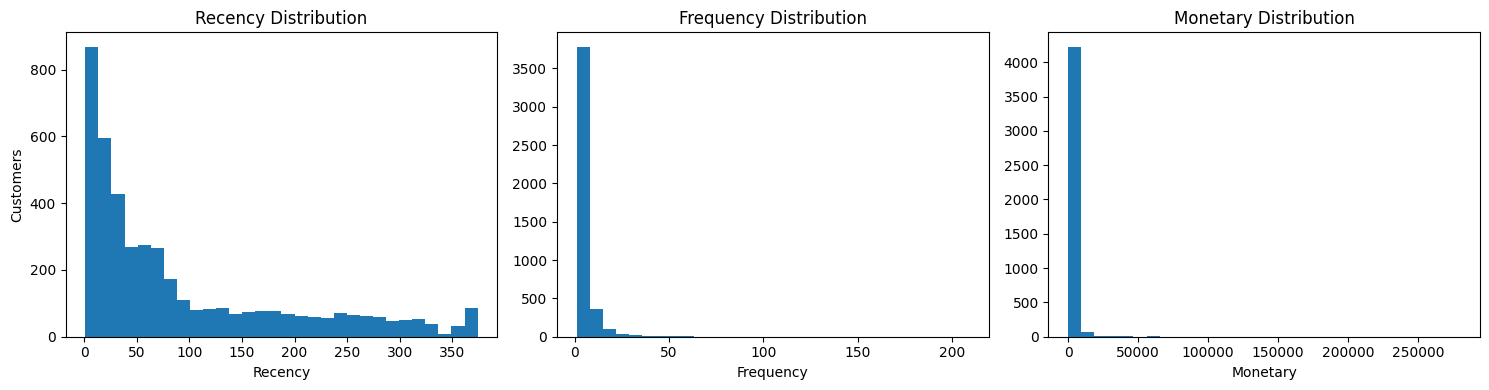

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(rfm["Recency"], bins=30)
axes[0].set_title("Recency Distribution")
axes[0].set_xlabel("Recency")
axes[0].set_ylabel("Customers")

axes[1].hist(rfm["Frequency"], bins=30)
axes[1].set_title("Frequency Distribution")
axes[1].set_xlabel("Frequency")

axes[2].hist(rfm["Monetary"], bins=30)
axes[2].set_title("Monetary Distribution")
axes[2].set_xlabel("Monetary")

plt.tight_layout()
plt.show()

## 8. Feature Transformation

RFM features may contain highly skewed distributions because a small number of customers may purchase very frequently or spend significantly more than other customers.

A logarithmic transformation is therefore applied using `log1p`, which computes `log(1 + x)` and safely handles zero values.

In [8]:
rfm_features = rfm[["Recency", "Frequency", "Monetary"]].copy()

rfm_log = np.log1p(rfm_features)

rfm_log.head()

,Recency,Frequency,Monetary
0,5.789960,0.693147,11.253955
1,1.098612,2.079442,8.368925
2,4.330733,1.609438,7.494564
3,2.995732,0.693147,7.472245
4,5.739793,0.693147,5.815324


## 9. Feature Scaling

The transformed RFM features are standardized using StandardScaler.

Standardization converts the features to approximately zero mean and unit variance. This is important because clustering algorithms based on distance calculations can be dominated by features with larger numerical scales.

The standardized dataset is used as the common input for K-Means, Hierarchical Clustering, and DBSCAN.

In [9]:
scaler = StandardScaler()

X = scaler.fit_transform(rfm_log)

X = pd.DataFrame(
    X,
    columns=["Recency", "Frequency", "Monetary"]
)

print("Scaled Dataset Shape:", X.shape)

X.head()

Scaled Dataset Shape: (4338, 3)


,Recency,Frequency,Monetary
0,1.461993,-0.955214,3.707716
1,-2.038734,1.074425,1.414903
2,0.373104,0.386304,0.720024
3,-0.623086,-0.955214,0.702287
4,1.424558,-0.955214,-0.614514


## 10. Visualization of Prepared Clustering Data


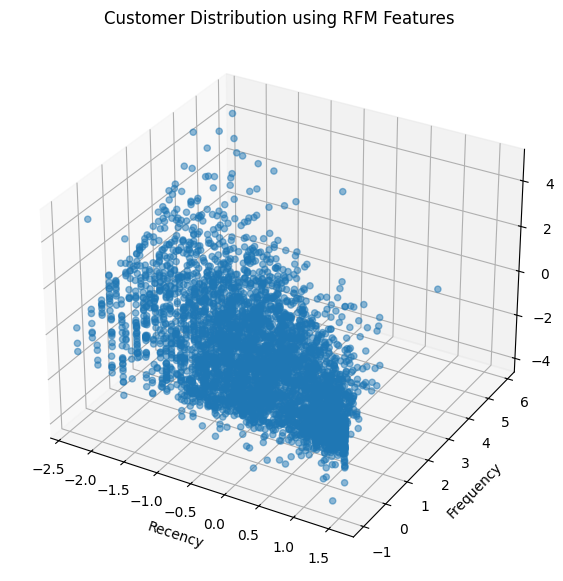

In [10]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X["Recency"],
    X["Frequency"],
    X["Monetary"],
    alpha=0.5
)

ax.set_xlabel("Recency")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary")
ax.set_title("Customer Distribution using RFM Features")

plt.show()

# 11. K-Means Clustering

K-Means is a partition-based clustering algorithm that divides the observations into K clusters.

The algorithm works by:

1. Selecting K initial centroids.
2. Assigning each data point to the nearest centroid.
3. Recalculating the centroid of each cluster.
4. Repeating the assignment and centroid update steps until convergence.

The number of clusters K must be specified before applying the algorithm.

The Elbow Method and Silhouette Score are used to determine a suitable number of clusters.

## 12. Elbow Method

The Elbow Method is used to determine an appropriate value of K.

It calculates the Within-Cluster Sum of Squares, represented by the K-Means inertia, for different values of K.

The point where the reduction in inertia begins to slow down is considered the elbow and can be selected as a suitable K value.

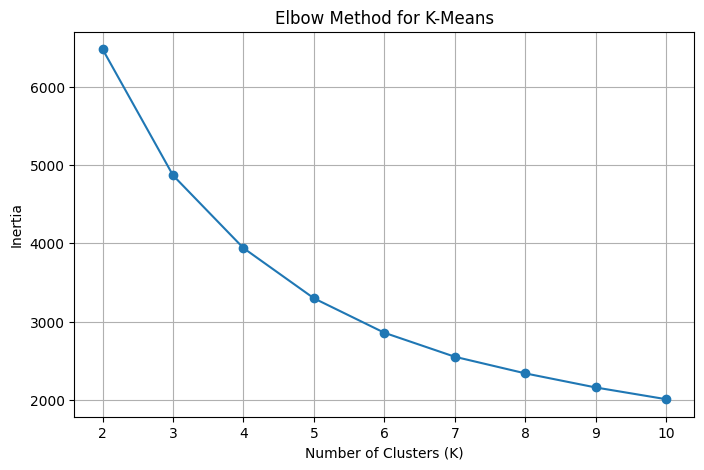

In [11]:
inertias = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.xticks(k_values)
plt.grid(True)
plt.show()

## 13. Selecting K using Silhouette Score

The Silhouette Score measures how well each data point fits within its assigned cluster compared with other clusters.

The score ranges from -1 to 1:

- A value close to 1 indicates well-separated clusters.
- A value close to 0 indicates overlapping clusters.
- A negative value may indicate inappropriate clustering.

The K value producing a higher silhouette score can be considered a better candidate.

In [12]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X)
    
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K = {k}: Silhouette Score = {score:.4f}")

K = 2: Silhouette Score = 0.4328
K = 3: Silhouette Score = 0.3365
K = 4: Silhouette Score = 0.3375
K = 5: Silhouette Score = 0.3162
K = 6: Silhouette Score = 0.3124
K = 7: Silhouette Score = 0.3092
K = 8: Silhouette Score = 0.3033
K = 9: Silhouette Score = 0.2811
K = 10: Silhouette Score = 0.2767


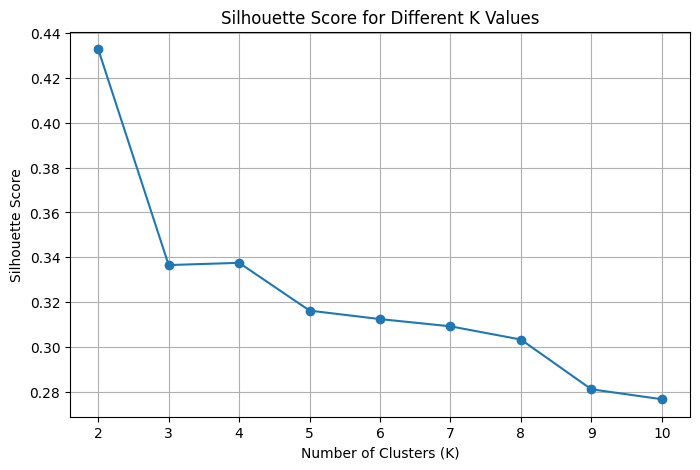

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")
plt.xticks(range(2, 11))
plt.grid(True)

plt.show()

## 15. Final K-Means Model

Based on the Elbow Method and Silhouette Score, a suitable value of K is selected and the final K-Means clustering model is trained.

In [14]:

best_k = 2

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X)

rfm["KMeans_Cluster"] = kmeans_labels

print("K-Means Cluster Counts:")
print(rfm["KMeans_Cluster"].value_counts().sort_index())

K-Means Cluster Counts:
KMeans_Cluster
0    2672
1    1666
Name: count, dtype: int64


## 16. K-Means Evaluation

The K-Means clustering result is evaluated using:

- Silhouette Score
- Davies-Bouldin Index

A higher Silhouette Score indicates better-separated clusters, while a lower Davies-Bouldin Index indicates better clustering.

In [15]:
kmeans_silhouette = silhouette_score(X, kmeans_labels)
kmeans_db = davies_bouldin_score(X, kmeans_labels)

print("K-Means Evaluation")
print("-------------------")
print(f"Silhouette Score: {kmeans_silhouette:.4f}")
print(f"Davies-Bouldin Index: {kmeans_db:.4f}")

K-Means Evaluation
-------------------
Silhouette Score: 0.4328
Davies-Bouldin Index: 0.8925


## 17. K-Means Cluster Visualization

The resulting customer clusters are visualized using the first two standardized RFM features.

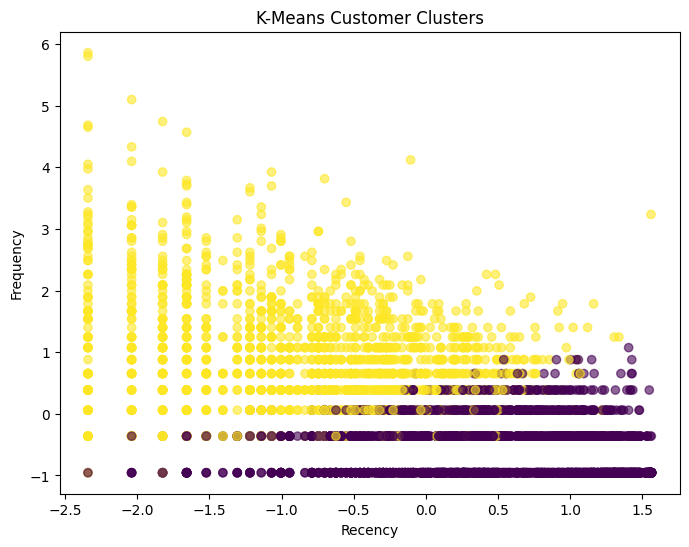

In [16]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X["Recency"],
    X["Frequency"],
    c=kmeans_labels,
    alpha=0.6
)

plt.xlabel("Recency")
plt.ylabel("Frequency")
plt.title("K-Means Customer Clusters")

plt.show()

# 18. Hierarchical Clustering

Hierarchical clustering creates a hierarchy of clusters.

Agglomerative hierarchical clustering follows a bottom-up approach:

1. Initially, every data point is treated as an individual cluster.
2. The two closest clusters are merged.
3. The process continues until all observations belong to a single cluster.

A dendrogram is used to visualize the hierarchy and determine a suitable number of clusters.

## 19. Dendrogram

A dendrogram is generated to visualize the hierarchical merging of observations.

Since the complete customer dataset may contain a large number of customers, a representative sample is used for dendrogram visualization. The final hierarchical clustering model is still applied to the complete prepared dataset.

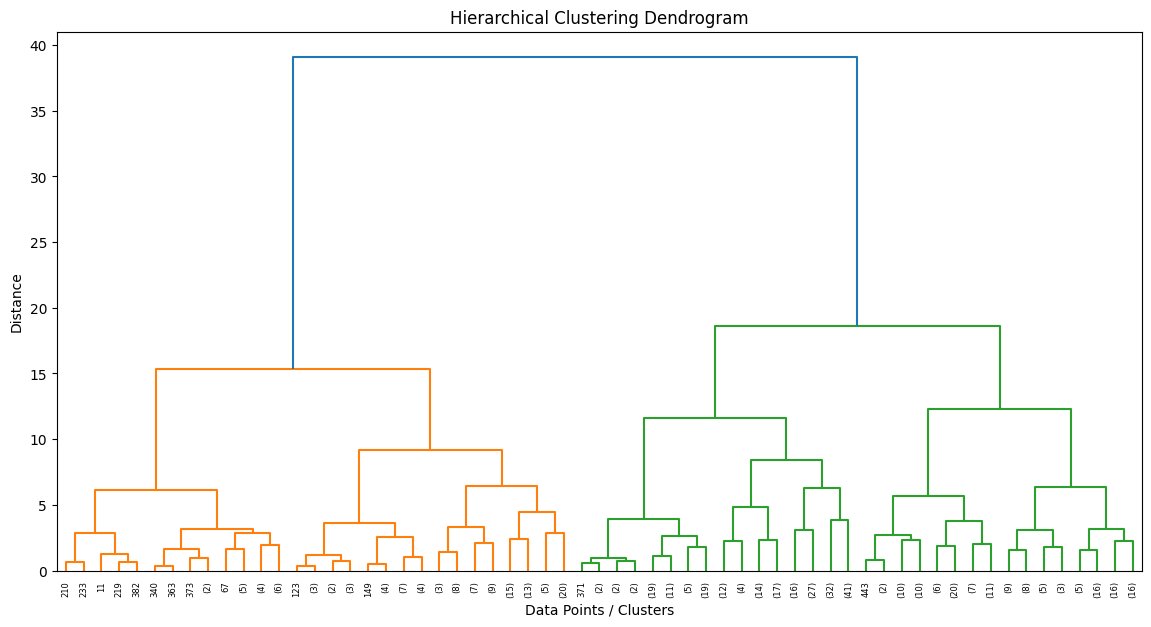

In [17]:
# Use a sample for dendrogram visualization
sample_size = min(500, len(X))

X_sample = X.sample(
    n=sample_size,
    random_state=42
)

linked = linkage(
    X_sample,
    method="ward"
)

plt.figure(figsize=(14, 7))

dendrogram(
    linked,
    truncate_mode="level",
    p=5
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points / Clusters")
plt.ylabel("Distance")

plt.show()

## 20. Selecting the Number of Clusters

Different numbers of clusters are tested using Agglomerative Hierarchical Clustering.

The Silhouette Score is used to compare the resulting cluster structures.

In [18]:
hierarchical_scores = []

for k in range(2, 11):
    hierarchical = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )
    
    labels = hierarchical.fit_predict(X)
    
    score = silhouette_score(X, labels)
    hierarchical_scores.append(score)

for k, score in zip(range(2, 11), hierarchical_scores):
    print(f"K = {k}: Silhouette Score = {score:.4f}")

K = 2: Silhouette Score = 0.4040
K = 3: Silhouette Score = 0.2843
K = 4: Silhouette Score = 0.2800
K = 5: Silhouette Score = 0.2805
K = 6: Silhouette Score = 0.2660
K = 7: Silhouette Score = 0.2582
K = 8: Silhouette Score = 0.2515
K = 9: Silhouette Score = 0.2500
K = 10: Silhouette Score = 0.2167


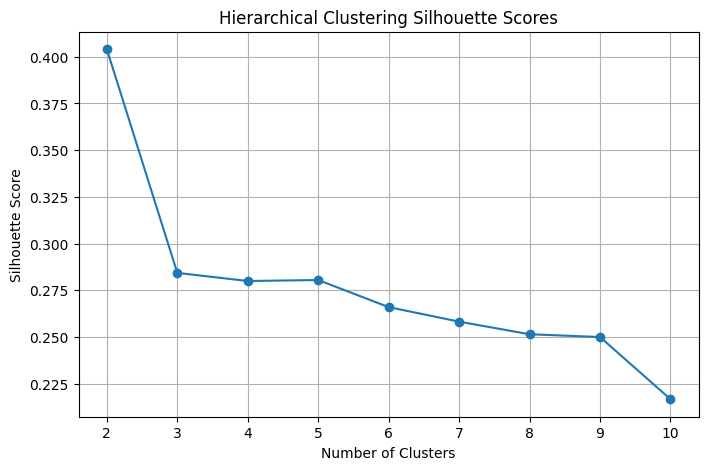

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    hierarchical_scores,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Hierarchical Clustering Silhouette Scores")
plt.xticks(range(2, 11))
plt.grid(True)

plt.show()

## 22. Final Hierarchical Clustering Model

The number of clusters is selected based on the silhouette analysis and the dendrogram. The final Agglomerative Hierarchical Clustering model is then applied to the complete dataset.

In [20]:

best_hierarchical_k = 2

hierarchical = AgglomerativeClustering(
    n_clusters=best_hierarchical_k,
    linkage="ward"
)

hierarchical_labels = hierarchical.fit_predict(X)

rfm["Hierarchical_Cluster"] = hierarchical_labels

print("Hierarchical Cluster Counts:")
print(
    rfm["Hierarchical_Cluster"]
    .value_counts()
    .sort_index()
)

Hierarchical Cluster Counts:
Hierarchical_Cluster
0    3233
1    1105
Name: count, dtype: int64


In [21]:
hierarchical_silhouette = silhouette_score(
    X,
    hierarchical_labels
)

hierarchical_db = davies_bouldin_score(
    X,
    hierarchical_labels
)

print("Hierarchical Clustering Evaluation")
print("-----------------------------------")
print(f"Silhouette Score: {hierarchical_silhouette:.4f}")
print(f"Davies-Bouldin Index: {hierarchical_db:.4f}")

Hierarchical Clustering Evaluation
-----------------------------------
Silhouette Score: 0.4040
Davies-Bouldin Index: 0.9405


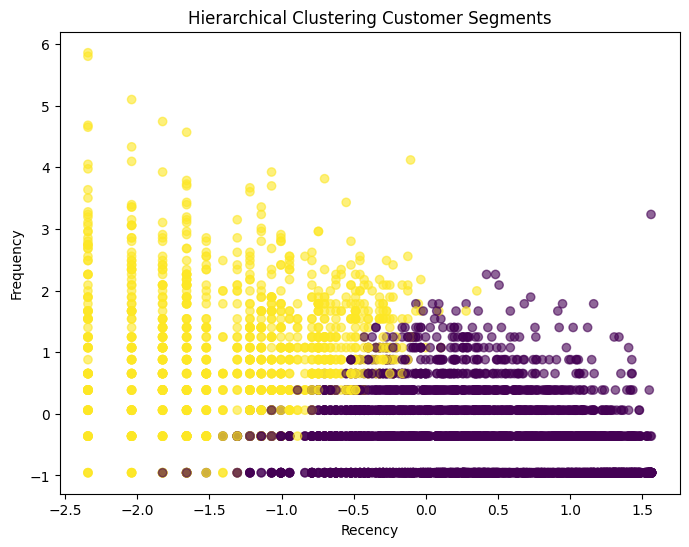

In [22]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X["Recency"],
    X["Frequency"],
    c=hierarchical_labels,
    alpha=0.6
)

plt.xlabel("Recency")
plt.ylabel("Frequency")
plt.title("Hierarchical Clustering Customer Segments")

plt.show()

# 25. DBSCAN Clustering

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a density-based clustering algorithm.

Unlike K-Means and Hierarchical Clustering, DBSCAN does not require the number of clusters to be specified beforehand.

DBSCAN uses two important parameters:

- **eps**: Maximum distance between two points for them to be considered neighbors.
- **min_samples**: Minimum number of neighboring points required to form a dense region.

DBSCAN can also identify noise or outlier points, which are assigned the cluster label `-1`.

## 26. Selecting DBSCAN Parameters

The `eps` parameter strongly affects DBSCAN performance.

A k-distance graph is used to estimate a suitable value for `eps`. The distance to the k-th nearest neighbor is calculated and sorted. A noticeable change or "elbow" in the graph can be used as a guideline for selecting `eps`.

For this implementation, `min_samples` is initially set to 5.

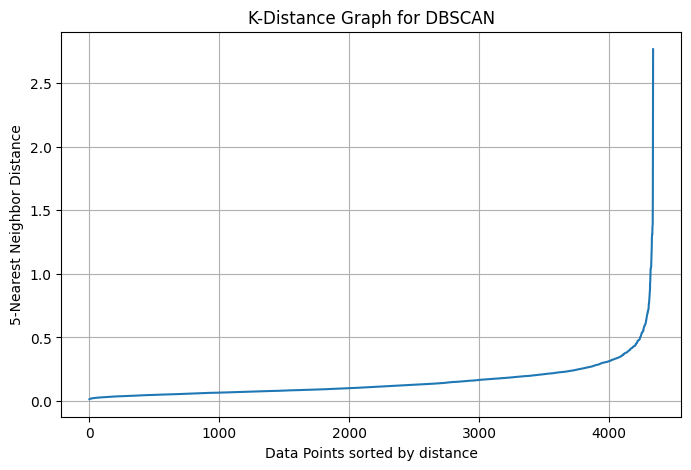

In [23]:
min_samples = 5

neighbors = NearestNeighbors(
    n_neighbors=min_samples
)

neighbors.fit(X)

distances, indices = neighbors.kneighbors(X)

k_distances = np.sort(
    distances[:, -1]
)

plt.figure(figsize=(8, 5))

plt.plot(k_distances)

plt.xlabel("Data Points sorted by distance")
plt.ylabel(f"{min_samples}-Nearest Neighbor Distance")
plt.title("K-Distance Graph for DBSCAN")

plt.grid(True)
plt.show()

## 27. DBSCAN Model

DBSCAN is applied using the selected `eps` and `min_samples` values.

Unlike K-Means, DBSCAN determines the number of clusters automatically based on the density of the observations.

In [24]:

eps_value = 0.5

dbscan = DBSCAN(
    eps=eps_value,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X)

rfm["DBSCAN_Cluster"] = dbscan_labels

print("DBSCAN Cluster Counts:")
print(
    rfm["DBSCAN_Cluster"]
    .value_counts()
    .sort_index()
)

DBSCAN Cluster Counts:
DBSCAN_Cluster
-1      62
 0    2791
 1    1485
Name: count, dtype: int64


## 28. DBSCAN Cluster Analysis

DBSCAN assigns the label `-1` to observations identified as noise or outliers.

The number of clusters and noise observations are calculated to understand the clustering result.

In [25]:
unique_labels = set(dbscan_labels)

n_clusters = len(
    unique_labels - {-1}
)

n_noise = list(dbscan_labels).count(-1)

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)
print("Percentage of noise points:", 
      round((n_noise / len(dbscan_labels)) * 100, 2), "%")

Number of clusters: 2
Number of noise points: 62
Percentage of noise points: 1.43 %


## 29. DBSCAN Evaluation

DBSCAN is evaluated using Silhouette Score and Davies-Bouldin Index when at least two valid clusters are produced.

Noise points labeled as `-1` are excluded from the evaluation because they do not belong to a cluster.

In [26]:
# Exclude noise points for evaluation
dbscan_mask = dbscan_labels != -1

dbscan_X_valid = X[dbscan_mask]
dbscan_labels_valid = dbscan_labels[dbscan_mask]

if len(set(dbscan_labels_valid)) >= 2:
    
    dbscan_silhouette = silhouette_score(
        dbscan_X_valid,
        dbscan_labels_valid
    )
    
    dbscan_db = davies_bouldin_score(
        dbscan_X_valid,
        dbscan_labels_valid
    )
    
    print("DBSCAN Evaluation")
    print("------------------")
    print(f"Silhouette Score: {dbscan_silhouette:.4f}")
    print(f"Davies-Bouldin Index: {dbscan_db:.4f}")

else:
    print("DBSCAN produced fewer than two valid clusters.")
    print("Adjust eps and/or min_samples.")

DBSCAN Evaluation
------------------
Silhouette Score: 0.2930
Davies-Bouldin Index: 1.0636


## 30. DBSCAN Cluster Visualization

The DBSCAN clustering results are visualized using Recency and Frequency.

Noise points identified by DBSCAN are represented by the cluster label `-1`.

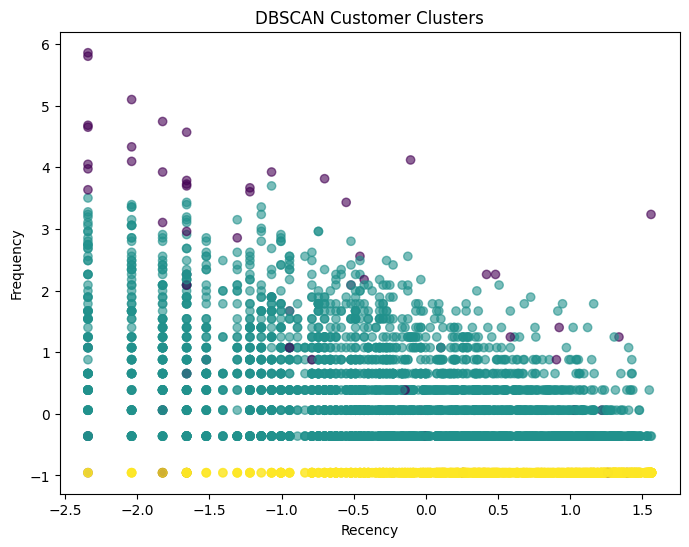

In [27]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X["Recency"],
    X["Frequency"],
    c=dbscan_labels,
    alpha=0.6
)

plt.xlabel("Recency")
plt.ylabel("Frequency")
plt.title("DBSCAN Customer Clusters")

plt.show()

# 31. Comparison of Clustering Algorithms

K-Means, Hierarchical Clustering, and DBSCAN are compared using clustering evaluation metrics.

The main evaluation measures are:

- **Silhouette Score**: Higher values generally indicate better-separated clusters.
- **Davies-Bouldin Index**: Lower values generally indicate better clustering.

The algorithms are applied to the same standardized RFM feature dataset to make the comparison consistent.

In [28]:
comparison = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Hierarchical",
        "DBSCAN"
    ],
    "Silhouette Score": [
        kmeans_silhouette,
        hierarchical_silhouette,
        dbscan_silhouette if 'dbscan_silhouette' in locals() else np.nan
    ],
    "Davies-Bouldin Index": [
        kmeans_db,
        hierarchical_db,
        dbscan_db if 'dbscan_db' in locals() else np.nan
    ]
})

comparison

,Algorithm,Silhouette Score,Davies-Bouldin Index
0,K-Means,0.432827,0.892499
1,Hierarchical,0.404010,0.940467
2,DBSCAN,0.293022,1.063614


In [29]:
kmeans_clusters = len(set(kmeans_labels))

hierarchical_clusters = len(set(hierarchical_labels))

dbscan_clusters = len(
    set(dbscan_labels) - {-1}
)

cluster_comparison = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Hierarchical",
        "DBSCAN"
    ],
    "Number of Clusters": [
        kmeans_clusters,
        hierarchical_clusters,
        dbscan_clusters
    ],
    "Noise Points": [
        0,
        0,
        n_noise
    ]
})

cluster_comparison

,Algorithm,Number of Clusters,Noise Points
0,K-Means,2,0
1,Hierarchical,2,0
2,DBSCAN,2,62


# 33. Scalability of Clustering Algorithms

## K-Means

K-Means is relatively scalable for large datasets because its computational complexity is approximately proportional to the number of observations, clusters, and iterations. It can therefore handle large datasets more efficiently than hierarchical clustering.

## Hierarchical Clustering

Hierarchical clustering is computationally and memory intensive, especially for large datasets. Constructing the hierarchy requires calculating distances between observations, making it less scalable than K-Means.

## DBSCAN

DBSCAN can be efficient when an appropriate spatial indexing structure is available. However, its performance can decrease for high-dimensional datasets or when suitable neighborhood parameters are difficult to determine.

## Overall

For large datasets, K-Means is generally the most scalable of the three methods. Hierarchical clustering is more computationally expensive, while DBSCAN provides useful density-based clustering and outlier detection but requires careful parameter selection.

## Discussion and Comparison of Clustering Algorithms

The clustering results show that **K-Means performed the best** among the three clustering algorithms for the given dataset.

| Algorithm | Silhouette Score | Davies-Bouldin Index | Number of Clusters | Noise Points |
|-----------|------------------:|---------------------:|-------------------:|-------------:|
| K-Means | **0.4328** | **0.8925** | 2 | 0 |
| Hierarchical | 0.4040 | 0.9405 | 2 | 0 |
| DBSCAN | 0.2930 | 1.0636 | 2 | 62 |

### K-Means

K-Means achieved the highest **Silhouette Score of 0.4328** and the lowest **Davies-Bouldin Index of 0.8925**. A higher Silhouette Score indicates better-separated and more compact clusters, while a lower Davies-Bouldin Index indicates better clustering quality. Therefore, K-Means produced the best overall clustering result.

The final K-Means model used **K = 2**, which was selected because it produced the highest Silhouette Score during the evaluation of different values of K.

The resulting cluster distribution was:

- Cluster 0: 2,672 records
- Cluster 1: 1,666 records

### Hierarchical Clustering

Hierarchical Clustering produced a **Silhouette Score of 0.4040** and a **Davies-Bouldin Index of 0.9405**. Its performance was relatively close to K-Means, making it the second-best performing algorithm.

The final model generated **2 clusters** with no noise points. However, its slightly lower Silhouette Score and higher Davies-Bouldin Index indicate that its clusters were less compact and separated compared with K-Means.

### DBSCAN

DBSCAN achieved the lowest **Silhouette Score of 0.2930** and the highest **Davies-Bouldin Index of 1.0636** among the three algorithms. Therefore, it produced the weakest clustering quality according to the selected evaluation metrics.

DBSCAN generated **2 clusters** and identified **62 observations as noise points**. The ability to identify noise is an advantage of DBSCAN, but its lower clustering scores indicate that the density-based approach was less suitable for the structure of this dataset.

### Overall Comparison

Based on both evaluation metrics, **K-Means performed better than Hierarchical Clustering and DBSCAN**. K-Means had the highest Silhouette Score and the lowest Davies-Bouldin Index, indicating that its clusters were more compact and better separated.

Hierarchical Clustering produced reasonably similar results, while DBSCAN performed comparatively poorly despite identifying 62 noise points.

Therefore, for this dataset, **K-Means is the most suitable clustering algorithm among the three tested approaches**.

### Conclusion

The experiment demonstrated the application and comparison of **K-Means, Hierarchical Clustering, and DBSCAN** on the same dataset. The results show that the performance of a clustering algorithm depends on the underlying structure of the data. For the given dataset, K-Means provided the best clustering quality based on the Silhouette Score and Davies-Bouldin Index.

# 35. Customer Segment Analysis

The resulting clusters are analyzed using the original RFM values to understand the characteristics of different customer segments.

In [30]:
kmeans_summary = rfm.groupby("KMeans_Cluster")[
    ["Recency", "Frequency", "Monetary"]
].mean()

kmeans_summary

,Recency,Frequency,Monetary
KMeans_Cluster,,,
0,134.091317,1.671033,495.594945
1,25.888956,8.443577,4539.603362


In [31]:
hierarchical_summary = rfm.groupby(
    "Hierarchical_Cluster"
)[["Recency", "Frequency", "Monetary"]].mean()

hierarchical_summary

,Recency,Frequency,Monetary
Hierarchical_Cluster,,,
0,120.502011,2.293845,874.832720
1,10.714932,10.059729,5483.144534


In [32]:
dbscan_summary = rfm.groupby(
    "DBSCAN_Cluster"
)[["Recency", "Frequency", "Monetary"]].mean()

dbscan_summary

,Recency,Frequency,Monetary
DBSCAN_Cluster,,,
-1,54.564516,33.209677,43840.678226
0,59.151200,5.370118,2021.950123
1,156.868013,1.000000,354.090270


# 36. Conclusion

Cluster analysis was performed on the Online Retail dataset using customer-level RFM features.

Three clustering algorithms were implemented:

1. K-Means Clustering
2. Hierarchical Clustering
3. DBSCAN Clustering

The transactional dataset was first cleaned and transformed into customer-level Recency, Frequency, and Monetary features. The features were log-transformed and standardized before clustering.

K-Means was evaluated using the Elbow Method and Silhouette Score to determine a suitable number of clusters. Hierarchical clustering was analyzed using a dendrogram and Silhouette Score. DBSCAN was implemented using the k-distance graph to select an appropriate `eps` value and was also used to identify potential noise and outlier observations.

The algorithms were compared using Silhouette Score, Davies-Bouldin Index, number of clusters, noise detection, and scalability.

The comparison demonstrates that different clustering algorithms can produce different customer segmentation structures because they use different clustering philosophies. Therefore, clustering performance should be evaluated using both quantitative metrics and the practical interpretability of the resulting clusters.